# SEMBRA — Surrogate for Elastomer Membrane Behavior under Radial loading and Actuation

### Charge-Controlled

This tool predicts the equilibrium state of a charge-controlled dielectric
elastomer membrane and identifies its electromechanical instability behavior under
combined mechanical and electrical loading. From three nondimensional inputs
— the Ogden hyperelastic exponent `alpha`, the electrical-loading parameter
`alpha_p`, and the inflation pressure `p` — the tool predicts the membrane
equilibrium state and reports diagnostics for the four principal failure
modes: electromechanical instability, wrinkling, electrical breakdown, and rupture.


In [1]:
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import sys, warnings, os
from pathlib import Path

# Walk up from cwd to find the directory containing sembra_cc/__init__.py.
_here = Path.cwd().resolve()
for _cand in [_here, *list(_here.parents)]:
    if (_cand / "sembra_cc" / "__init__.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import io
    import base64
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    from IPython.display import HTML, display
    from sembra_cc.wrapper import predict
    from sembra_cc.utils import compute_stress, detect_wrinkling, compute_max_electric_field
    from sembra_cc.envelope import load_envelope_models, predict_p_crit
    from sembra_cc.data import load_full_dataset, split_stable_unstable
    from sembra_cc import PROJECT_ROOT, LOGS_DIR

    # Warm cached resources so the first user run is fast and silent.
    _ = predict(1.6, 0.10, 0.5)


## Usage

Edit `alpha` (recommended range [1.2, 2.0]), `alpha_p` (recommended range [0, 0.4]), and `p` in the cell below and run it. The output
includes the equilibrium state, diagnostics for the four failure modes, and
two figures: the principal Cauchy stresses on the deformed dome, and the
location of the query in the (α_p, p) plane at the chosen `alpha`.

Plots are saved to `logs/plots/user_queries/` and overwritten on each re-run.

                  Sembra — Charge-Controlled                  

  Input
    alpha    = 1.4
    alpha_p  = 0.24
    p        = 1.0

  Equilibrium state
    lambda_0 = 1.367813
    eta_0    = 0.685504
    det_H    = +0.431523

  Failure modes
    Electromechanical instability:  NOT DETECTED ✓
      p_crit ≈ 1.4650,  pressure difference = 31.74%
    Wrinkling instability:      NOT DETECTED ✓
    Peak electric field:        Ē_max = 0.7162
    Peak stresses
      σ_1_max = 1.0658 at r ≈ 0.00
      σ_2_max = 1.0658 at r ≈ 0.00

  Equilibrium residuals: |∂Π/∂λ_0| = 9.47e-05, |∂Π/∂η_0| = 2.60e-05



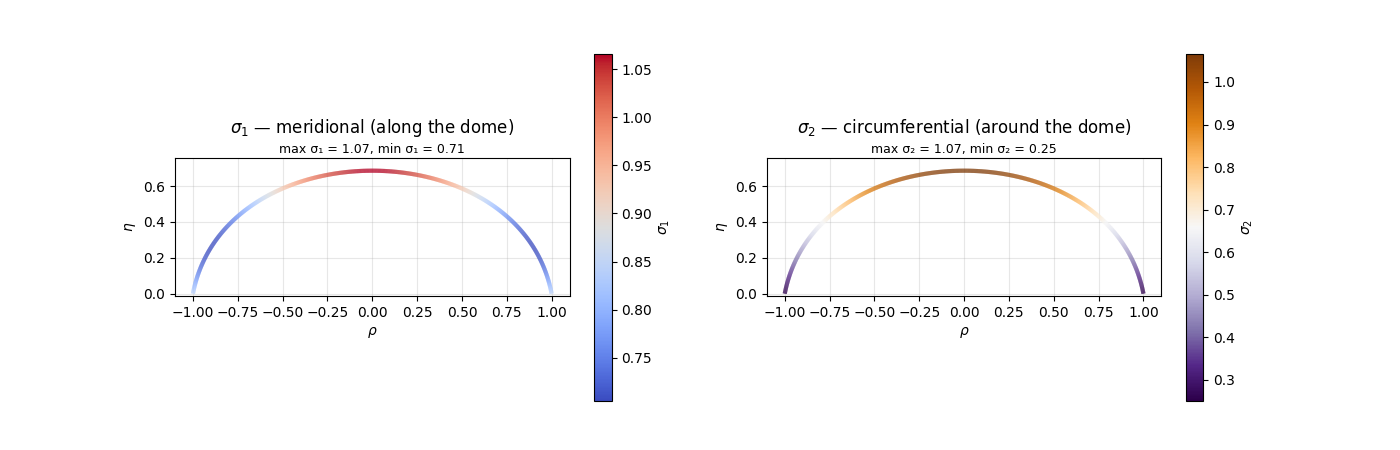


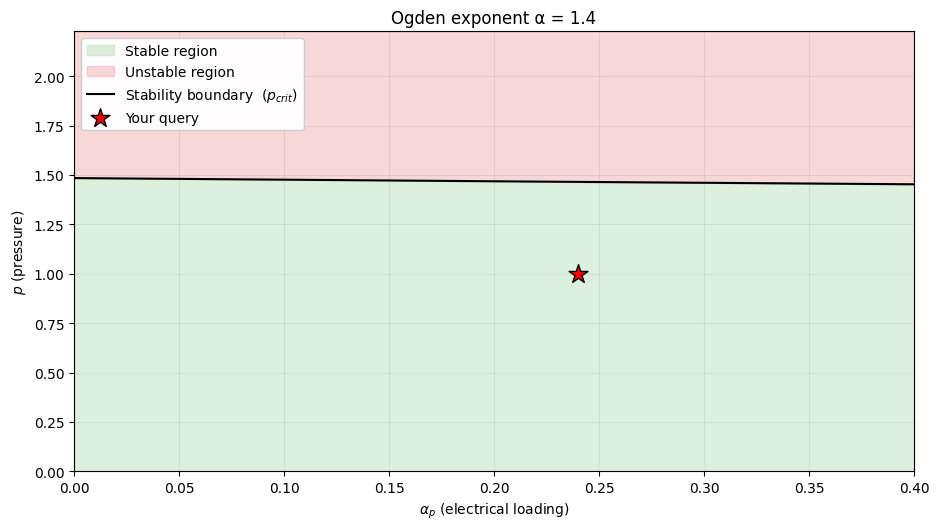

In [2]:
alpha = 1.4
alpha_p = 0.24
p = 1.0

import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    result = predict(alpha, alpha_p, p)

    p_crit = float(result.diagnostics.get("p_crit", float("nan")))
    pull_in_verdict = "NOT DETECTED ✓" if result.stable else "DETECTED ✗"
    margin_pct = abs((p - p_crit) / p_crit * 100.0) if p_crit > 0 else float("nan")

    _state_invalid = math.isnan(result.lambda_0) or math.isnan(result.eta_0)

    if _state_invalid:
        wrinkling_block = "    Wrinkling instability:      N/A (no stable region)"
        E_line = "    Peak electric field:        N/A"
        peak_stresses_block = (
            "    Peak stresses\n"
            "      σ_1_max = N/A\n"
            "      σ_2_max = N/A"
        )
        _piece_b2 = "\n  Equilibrium residuals: not applicable for this branch"
        r_grid = None
        rho_grid = None
        eta_grid = None
        stress = None
        sigma_1 = None
        sigma_2 = None
    else:
        # Deformed geometry + stresses on a 401-point grid.
        r_grid = np.linspace(0.0, 1.0, 401)
        lambda_2_grid = r_grid**2 + result.lambda_0 * (1.0 - r_grid**2)
        rho_grid = r_grid * lambda_2_grid
        eta_grid = result.eta_0 * (1.0 - r_grid**2)

        stress = compute_stress(alpha, alpha_p, p, r_grid)
        sigma_1 = stress["sigma_1"]
        sigma_2 = stress["sigma_2"]

        wrinkling = detect_wrinkling(stress)
        if wrinkling["detected"]:
            wrinkling_verdict = "DETECTED ✗"
            parts = []
            if wrinkling["sigma_1_intervals"]:
                r_mids = ", ".join(f"{interval[2]:.2f}" for interval in wrinkling["sigma_1_intervals"])
                parts.append(f"σ_1 near r ≈ {r_mids}")
            if wrinkling["sigma_2_intervals"]:
                r_mids = ", ".join(f"{interval[2]:.2f}" for interval in wrinkling["sigma_2_intervals"])
                parts.append(f"σ_2 near r ≈ {r_mids}")
            wrinkling_detail = "Triggered by " + " and ".join(parts)
            wrinkling_block = (
                f"    Wrinkling instability:      {wrinkling_verdict}\n"
                f"      {wrinkling_detail}"
            )
        else:
            wrinkling_verdict = "NOT DETECTED ✓"
            wrinkling_block = f"    Wrinkling instability:      {wrinkling_verdict}"

        peak_e_max = compute_max_electric_field(result.lambda_0, result.eta_0)
        E_line = f"    Peak electric field:        Ē_max = {peak_e_max:.4f}"

        s1_argmax = int(np.argmax(sigma_1))
        s2_argmax = int(np.argmax(sigma_2))
        s1_max = float(sigma_1[s1_argmax])
        s2_max = float(sigma_2[s2_argmax])
        s1_argmax_r = float(r_grid[s1_argmax])
        s2_argmax_r = float(r_grid[s2_argmax])
        peak_stresses_block = (
            f"    Peak stresses\n"
            f"      σ_1_max = {s1_max:.4f} at r ≈ {s1_argmax_r:.2f}\n"
            f"      σ_2_max = {s2_max:.4f} at r ≈ {s2_argmax_r:.2f}"
        )

        res_l = abs(result.diagnostics.get("dPi_dlambda_0", float("nan")))
        res_e = abs(result.diagnostics.get("dPi_deta_0", float("nan")))
        if math.isnan(res_l) or math.isnan(res_e):
            _piece_b2 = "\n  Equilibrium residuals: not applicable for this branch"
        else:
            _piece_b2 = (
                f"\n  Equilibrium residuals: "
                f"|∂Π/∂λ_0| = {res_l:.2e}, |∂Π/∂η_0| = {res_e:.2e}"
            )

    _bar = "=" * 62
    _title_line = "Sembra — Charge-Controlled".center(62)

    _piece_a = (
        f"{_bar}\n"
        f"{_title_line}\n"
        f"{_bar}\n"
        f"\n"
        f"  Input\n"
        f"    alpha    = {alpha}\n"
        f"    alpha_p  = {alpha_p}\n"
        f"    p        = {p}\n"
        f"\n"
        f"  Equilibrium state\n"
        f"    lambda_0 = {result.lambda_0:.6f}\n"
        f"    eta_0    = {result.eta_0:.6f}\n"
        f"    det_H    = {result.det_H:+.6f}"
    )
    print(_piece_a)

    _piece_b = (
        f"\n"
        f"  Failure modes\n"
        f"    Electromechanical instability:  {pull_in_verdict}\n"
        f"      p_crit ≈ {p_crit:.4f},  pressure difference = {margin_pct:.2f}%\n"
        f"{wrinkling_block}\n"
        f"{E_line}\n"
        f"{peak_stresses_block}"
    )
    print(_piece_b)

    print(_piece_b2)

    _piece_c = f"\n{_bar}"
    print(_piece_c)

    if _state_invalid:
        print("\nStress and design-space figures not available for inputs outside the stable envelope.")

    if not _state_invalid:
        def _make_mirrored_segments(rho, eta):
            # Segments on +rho side, then -rho side, traversed in order.
            pts_right = np.column_stack([rho, eta])
            pts_left = np.column_stack([-rho, eta])
            segs_right = np.stack([pts_right[:-1], pts_right[1:]], axis=1)
            segs_left = np.stack([pts_left[:-1], pts_left[1:]], axis=1)
            return np.concatenate([segs_right, segs_left], axis=0)

        def _mirrored_values(values):
            # Use same scalar value for matching segment on the left side.
            v_right = 0.5 * (values[:-1] + values[1:])
            return np.concatenate([v_right, v_right])

        fig_stress, (ax_s1, ax_s2) = plt.subplots(1, 2, figsize=(14, 4.5))

        segs = _make_mirrored_segments(rho_grid, eta_grid)

        s1_max_idx = int(np.argmax(sigma_1))
        s1_min_idx = int(np.argmin(sigma_1))
        s2_max_idx = int(np.argmax(sigma_2))
        s2_min_idx = int(np.argmin(sigma_2))

        sub_s1 = f"max σ₁ = {sigma_1[s1_max_idx]:.2f}, min σ₁ = {sigma_1[s1_min_idx]:.2f}"
        sub_s2 = f"max σ₂ = {sigma_2[s2_max_idx]:.2f}, min σ₂ = {sigma_2[s2_min_idx]:.2f}"

        rho_max = float(np.abs(rho_grid).max())
        eta_max = float(eta_grid.max())
        x_pad = 0.10 * rho_max
        y_pad = 0.10 * eta_max

        vals_s1 = _mirrored_values(sigma_1)
        lc_s1 = LineCollection(segs, cmap="coolwarm", linewidths=3.0)
        lc_s1.set_array(vals_s1)
        ax_s1.add_collection(lc_s1)
        ax_s1.grid(alpha=0.3)
        ax_s1.set_xlabel(r"$\rho$")
        ax_s1.set_ylabel(r"$\eta$")
        ax_s1.set_title(r"$\sigma_1$ — meridional (along the dome)", pad=18)
        ax_s1.text(0.5, 1.02, sub_s1, transform=ax_s1.transAxes, ha="center",
                   va="bottom", fontsize=9, color="black")
        cb_s1 = fig_stress.colorbar(lc_s1, ax=ax_s1)
        cb_s1.set_label(r"$\sigma_1$")

        vals_s2 = _mirrored_values(sigma_2)
        lc_s2 = LineCollection(segs, cmap="PuOr_r", linewidths=3.0)
        lc_s2.set_array(vals_s2)
        ax_s2.add_collection(lc_s2)
        ax_s2.grid(alpha=0.3)
        ax_s2.set_xlabel(r"$\rho$")
        ax_s2.set_ylabel(r"$\eta$")
        ax_s2.set_title(r"$\sigma_2$ — circumferential (around the dome)", pad=18)
        ax_s2.text(0.5, 1.02, sub_s2, transform=ax_s2.transAxes, ha="center",
                   va="bottom", fontsize=9, color="black")
        cb_s2 = fig_stress.colorbar(lc_s2, ax=ax_s2)
        cb_s2.set_label(r"$\sigma_2$")

        for ax in (ax_s1, ax_s2):
            ax.set_xlim(-rho_max - x_pad, rho_max + x_pad)
            ax.set_ylim(0 - 0.02 * eta_max, eta_max + y_pad)
            ax.set_aspect("equal")

        # Design-space figure at the user's alpha.
        fig_ds, ax_ds = plt.subplots(figsize=(14, 5.5))
        fig_ds.subplots_adjust(left=0.20, right=0.80, top=0.92, bottom=0.12)

        gp_p, _gp_l = load_envelope_models()
        aps_full = np.linspace(0.0, 0.40, 200)
        pcs_full = predict_p_crit(gp_p, np.full_like(aps_full, alpha), aps_full)
        pcs_full = np.clip(pcs_full, 0.0, None)

        # Find first alpha_p at which p_crit drops to zero (or stay at 0.40 if never).
        nonzero = np.where(pcs_full > 1e-9)[0]
        if len(nonzero) > 0:
            last_nonzero = nonzero[-1]
            if last_nonzero < len(aps_full) - 1:
                ap_max_envelope = float(aps_full[last_nonzero + 1])
            else:
                ap_max_envelope = 0.40
        else:
            ap_max_envelope = 0.40

        x_max = max(ap_max_envelope, alpha_p * 1.05)
        x_max = min(x_max, 0.40)

        aps_vis = np.linspace(0.0, x_max, 200)
        pcs_vis = np.clip(predict_p_crit(gp_p, np.full_like(aps_vis, alpha), aps_vis), 0.0, None)

        curve_max = float(np.max(pcs_vis))
        y_max = max(1.5 * curve_max, p * 1.05)

        ax_ds.fill_between(aps_vis, 0.0, pcs_vis, color="#9fd49f", alpha=0.35, label="Stable region")
        ax_ds.fill_between(aps_vis, pcs_vis, y_max, color="#e89090", alpha=0.35, label="Unstable region")
        ax_ds.plot(aps_vis, pcs_vis, color="black", linewidth=1.5, label=r"Stability boundary  ($p_{crit}$)")
        ax_ds.scatter([alpha_p], [p], marker="*", s=200, color="red",
                      edgecolors="black", linewidths=1.0, zorder=10, label="Your query")

        ax_ds.set_xlim(0.0, x_max)
        ax_ds.set_ylim(0.0, y_max)
        ax_ds.set_title(f"Ogden exponent α = {alpha}")
        ax_ds.set_xlabel(r"$\alpha_p$ (electrical loading)")
        ax_ds.set_ylabel(r"$p$ (pressure)")
        legend_loc = "upper right" if alpha_p <= x_max / 2.0 else "upper left"
        ax_ds.legend(loc=legend_loc, framealpha=0.95)
        ax_ds.grid(alpha=0.3)
        ax_ds.set_axisbelow(True)

        # Save PNGs silently (no announcement).
        _out_dir = LOGS_DIR / "plots" / "user_queries"
        _out_dir.mkdir(parents=True, exist_ok=True)
        _stem = f"a{alpha}_ap{alpha_p}_p{p}".replace(".", "p")
        fig_stress.savefig(_out_dir / f"stress_{_stem}.png", dpi=150, bbox_inches="tight")
        fig_ds.savefig(_out_dir / f"design_space_{_stem}.png", dpi=150)

        # Display the stress figure inline normally, then close it to prevent a
        # second auto-display from the inline backend at end-of-cell.
        display(fig_stress)
        plt.close(fig_stress)

        # Render the design-space figure via a centered HTML wrapper so it occupies
        # only ~65% of the notebook output width (the matplotlib inline backend
        # otherwise renders it at full output width regardless of figure size).
        _buf = io.BytesIO()
        fig_ds.savefig(_buf, format="png", dpi=100, bbox_inches="tight")
        _buf.seek(0)
        _img_b64 = base64.b64encode(_buf.read()).decode("ascii")
        _html = (
            '<div style="text-align: center; width: 100%;">'
            f'<img src="data:image/png;base64,{_img_b64}" '
            'style="max-width: 65%; height: auto; display: inline-block;" />'
            '</div>'
        )
        display(HTML(_html))
        plt.close(fig_ds)
